In [1]:
#Referencia: https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data

import kagglehub

# Download latest version
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\000010478\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Directorio donde están los CSV
directorio = Path(path)      # Cambia por tu ruta

# Lista de DataFrames
dfs = []

# Cargar todos los CSV
for archivo in directorio.glob("*.csv"):
    df = pd.read_csv(archivo)
    dfs.append(df)

print(f"Se cargaron {len(dfs)} archivos.")

Se cargaron 4 archivos.


In [3]:
data=pd.concat(dfs, ignore_index=True) #Se concatenan los dataframes para ser uno solo
data.sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID
19360643,1,2016-01-19 08:16:53,2016-01-19 08:21:10,1,0.50,-73.975510,40.751793,NaN,N,-73.972488,40.746761,1,5.0,0.0,0.5,0.00,0.0,0.3,5.80,1.0
6112411,1,2015-01-26 01:22:07,2015-01-26 01:32:07,1,3.80,-73.946915,40.803463,1.0,N,-73.934410,40.844578,2,13.5,0.5,0.5,0.00,0.0,0.3,14.80,NaN
43073681,2,2016-03-24 06:50:04,2016-03-24 06:58:35,2,2.09,-73.983345,40.738846,NaN,N,-74.004555,40.719151,1,9.0,0.0,0.5,1.96,0.0,0.3,11.76,1.0
7754136,2,2015-01-11 14:09:12,2015-01-11 14:14:21,1,0.84,-73.958473,40.769855,1.0,N,-73.967361,40.763275,1,5.5,0.0,0.5,1.65,0.0,0.3,7.95,NaN
12605416,2,2015-01-02 23:18:50,2015-01-02 23:30:56,6,2.80,-73.966850,40.793945,1.0,N,-73.941170,40.815128,1,11.0,0.5,0.5,3.00,0.0,0.3,15.30,NaN
31731336,1,2016-02-24 19:19:25,2016-02-24 19:21:40,1,0.30,-73.960464,40.775726,NaN,N,-73.957298,40.778393,1,3.5,1.0,0.5,1.00,0.0,0.3,6.30,1.0
20303636,2,2016-01-30 18:53:16,2016-01-30 19:14:24,2,6.05,-74.010742,40.711712,NaN,N,-73.982109,40.761459,2,21.5,0.0,0.5,0.00,0.0,0.3,22.30,1.0
37030407,1,2016-03-05 14:58:04,2016-03-05 15:01:02,1,0.50,-73.964294,40.797314,NaN,N,-73.971466,40.794361,1,4.0,0.0,0.5,0.00,0.0,0.3,4.80,1.0
13814272,1,2016-01-04 19:07:13,2016-01-04 19:16:11,1,1.30,-73.993645,40.746201,NaN,N,-73.978348,40.752659,2,8.0,1.0,0.5,0.00,0.0,0.3,9.80,1.0
29680725,1,2016-02-20 12:50:36,2016-02-20 13:01:53,1,1.80,-73.983665,40.721519,NaN,N,-74.006027,40.735668,1,9.5,0.0,0.5,2.05,0.0,0.3,12.35,1.0


In [4]:
#Revisión de los datos para poder procesarlos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47248845 entries, 0 to 47248844
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             float64
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
 19  RatecodeID             float64
dtypes: float64(14), int64(3), str(3)
memory usage: 8.8 GB


In [5]:
#Vamos a convertir las fechas y extraer información como día de la semana, hora del día y mes del año. Esto nos permitirá analizar los datos de manera más efectiva.
data["tpep_pickup_datetime"] = pd.to_datetime(data["tpep_pickup_datetime"])
data["tpep_dropoff_datetime"] = pd.to_datetime(data["tpep_dropoff_datetime"])
data["day_of_week"] = data["tpep_pickup_datetime"].dt.dayofweek
data["hour_of_day"] = data["tpep_pickup_datetime"].dt.hour
data["month"] = data["tpep_pickup_datetime"].dt.month
data.sample(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month
19023225,2,2016-01-27 21:28:06,2016-01-27 21:40:23,1,2.02,-73.982964,40.773277,NaN,N,-73.976318,...,0.5,0.5,0.00,0.0,0.3,11.30,1.0,2,21,1
37903839,2,2016-03-11 21:03:37,2016-03-11 21:17:30,1,1.95,-73.955833,40.819370,NaN,N,-73.942055,...,0.5,0.5,0.00,0.0,0.3,12.30,1.0,4,21,3
45713989,1,2016-03-27 21:39:51,2016-03-27 21:44:18,2,0.90,-73.991966,40.748692,NaN,N,-73.980461,...,0.5,0.5,1.00,0.0,0.3,7.80,1.0,6,21,3
40986453,1,2016-03-19 01:15:42,2016-03-19 01:32:06,3,1.90,-73.987549,40.728653,NaN,N,-74.009811,...,0.5,0.5,0.64,0.0,0.3,13.44,1.0,5,1,3
40192468,2,2016-03-17 08:31:59,2016-03-17 08:37:13,1,0.48,-73.954735,40.777782,NaN,N,-73.960533,...,0.0,0.5,0.00,0.0,0.3,5.80,1.0,3,8,3
5761073,2,2015-01-06 18:58:29,2015-01-06 19:26:49,2,13.93,-73.777100,40.646416,1.0,N,-73.762444,...,1.0,0.5,0.00,0.0,0.3,39.30,NaN,1,18,1
15012659,2,2016-01-15 21:51:33,2016-01-15 22:04:37,1,1.49,-73.971153,40.755165,NaN,N,-73.986336,...,0.5,0.5,0.00,0.0,0.3,10.80,1.0,4,21,1
12339182,2,2015-01-19 15:30:12,2015-01-19 15:33:05,1,0.42,-73.993576,40.729393,1.0,N,-73.999168,...,0.0,0.5,0.00,0.0,0.3,4.80,NaN,0,15,1
33121026,2,2016-02-20 20:29:51,2016-02-20 20:43:56,1,1.08,-74.000031,40.726646,NaN,N,-73.985046,...,0.5,0.5,2.00,0.0,0.3,12.80,1.0,5,20,2
18879152,2,2016-01-15 19:31:13,2016-01-15 19:38:08,1,0.95,-73.979393,40.771328,NaN,N,-73.979774,...,1.0,0.5,1.00,0.0,0.3,9.30,1.0,4,19,1


In [6]:
#Campo de duración del viaje
data["trip_duration"] = (data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"]).dt.total_seconds() / 60  # Duración en minutos
data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month,trip_duration
count,4.724884e+07,47248845,47248845,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,1.274899e+07,4.724884e+07,4.724884e+07,...,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,3.449986e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,1.529570e+00,2015-11-01 19:34:22.551143,2015-11-01 19:49:31.111697,1.667040e+00,7.508418e+00,-7.276452e+01,4.008470e+01,1.036901e+00,-7.282501e+01,4.011889e+01,...,4.977081e-01,1.794568e+00,2.843674e-01,2.952466e-01,1.559273e+01,1.039150e+00,3.100029e+00,1.362430e+01,1.757774e+00,1.514268e+01
min,1.000000e+00,2015-01-01 00:00:00,2015-01-01 00:00:00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-7.401667e+02,-7.703949e+01,...,-1.000000e+00,-2.208000e+02,-9.999000e+01,-3.000000e-01,-9.584000e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.371001e+05
25%,1.000000e+00,2015-01-30 07:34:06,2015-01-30 07:47:19,1.000000e+00,1.000000e+00,-7.399166e+01,4.073611e+01,1.000000e+00,-7.399120e+01,4.073459e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,1.000000e+00,1.000000e+00,9.000000e+00,1.000000e+00,6.316667e+00
50%,2.000000e+00,2016-01-31 21:20:27,2016-01-31 21:35:50,1.000000e+00,1.690000e+00,-7.398155e+01,4.075335e+01,1.000000e+00,-7.397962e+01,4.075380e+01,...,5.000000e-01,1.250000e+00,0.000000e+00,3.000000e-01,1.160000e+01,1.000000e+00,3.000000e+00,1.400000e+01,1.000000e+00,1.045000e+01
75%,2.000000e+00,2016-03-02 05:54:00,2016-03-02 06:08:11,2.000000e+00,3.090000e+00,-7.396657e+01,4.076779e+01,1.000000e+00,-7.396225e+01,4.076920e+01,...,5.000000e-01,2.260000e+00,0.000000e+00,3.000000e-01,1.715000e+01,1.000000e+00,5.000000e+00,1.900000e+01,3.000000e+00,1.678333e+01
max,2.000000e+00,2016-03-31 23:59:59,2016-06-29 15:58:16,9.000000e+00,1.907263e+07,9.464387e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,...,8.970000e+01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+00,5.485556e+05
std,4.991248e-01,NaN,NaN,1.322092e+00,6.487658e+03,9.381830e+00,5.168528e+00,6.732240e-01,9.150215e+00,5.040345e+00,...,4.672388e-02,5.747384e+02,1.657184e+00,3.812080e-02,5.801393e+02,5.564537e-01,1.927974e+00,6.370660e+00,8.369175e-01,3.790111e+02


In [7]:
#Miremos las características del df para ver qué necesitamos filtrar. 
data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month,trip_duration
count,4.724884e+07,47248845,47248845,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,1.274899e+07,4.724884e+07,4.724884e+07,...,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,3.449986e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,1.529570e+00,2015-11-01 19:34:22.551143,2015-11-01 19:49:31.111697,1.667040e+00,7.508418e+00,-7.276452e+01,4.008470e+01,1.036901e+00,-7.282501e+01,4.011889e+01,...,4.977081e-01,1.794568e+00,2.843674e-01,2.952466e-01,1.559273e+01,1.039150e+00,3.100029e+00,1.362430e+01,1.757774e+00,1.514268e+01
min,1.000000e+00,2015-01-01 00:00:00,2015-01-01 00:00:00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-7.401667e+02,-7.703949e+01,...,-1.000000e+00,-2.208000e+02,-9.999000e+01,-3.000000e-01,-9.584000e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.371001e+05
25%,1.000000e+00,2015-01-30 07:34:06,2015-01-30 07:47:19,1.000000e+00,1.000000e+00,-7.399166e+01,4.073611e+01,1.000000e+00,-7.399120e+01,4.073459e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,1.000000e+00,1.000000e+00,9.000000e+00,1.000000e+00,6.316667e+00
50%,2.000000e+00,2016-01-31 21:20:27,2016-01-31 21:35:50,1.000000e+00,1.690000e+00,-7.398155e+01,4.075335e+01,1.000000e+00,-7.397962e+01,4.075380e+01,...,5.000000e-01,1.250000e+00,0.000000e+00,3.000000e-01,1.160000e+01,1.000000e+00,3.000000e+00,1.400000e+01,1.000000e+00,1.045000e+01
75%,2.000000e+00,2016-03-02 05:54:00,2016-03-02 06:08:11,2.000000e+00,3.090000e+00,-7.396657e+01,4.076779e+01,1.000000e+00,-7.396225e+01,4.076920e+01,...,5.000000e-01,2.260000e+00,0.000000e+00,3.000000e-01,1.715000e+01,1.000000e+00,5.000000e+00,1.900000e+01,3.000000e+00,1.678333e+01
max,2.000000e+00,2016-03-31 23:59:59,2016-06-29 15:58:16,9.000000e+00,1.907263e+07,9.464387e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,...,8.970000e+01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+00,5.485556e+05
std,4.991248e-01,NaN,NaN,1.322092e+00,6.487658e+03,9.381830e+00,5.168528e+00,6.732240e-01,9.150215e+00,5.040345e+00,...,4.672388e-02,5.747384e+02,1.657184e+00,3.812080e-02,5.801393e+02,5.564537e-01,1.927974e+00,6.370660e+00,8.369175e-01,3.790111e+02


In [8]:
#Organización de los datos para poder analizarlos mejor. Eliminamos columnas que no nos interesan y filtramos los datos para que tengan sentido.
eliminar=['VendorID','store_and_fwd_flag','RatecodeID']
minimo={'passenger_count':1,'trip_distance':0.1,'fare_amount':0.1,'tip_amount':0.0,'tolls_amount':0.0,'total_amount':0.1}
maximo={'trip_distance':200,'fare_amount':500,'tip_amount':100,'tolls_amount':100,'total_amount':500}
data=data.drop(columns=eliminar)
for col, min_val in minimo.items():
    data = data[data[col] >= min_val]
for col, max_val in maximo.items():
    data = data[data[col] <= max_val]


Text(0.5, 1.0, 'Distribución del pago de los viajes')

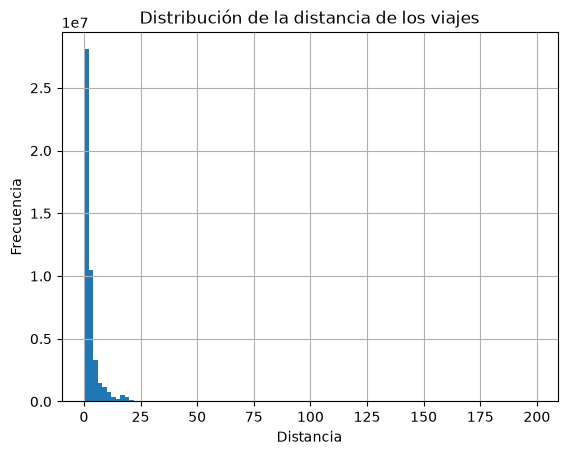

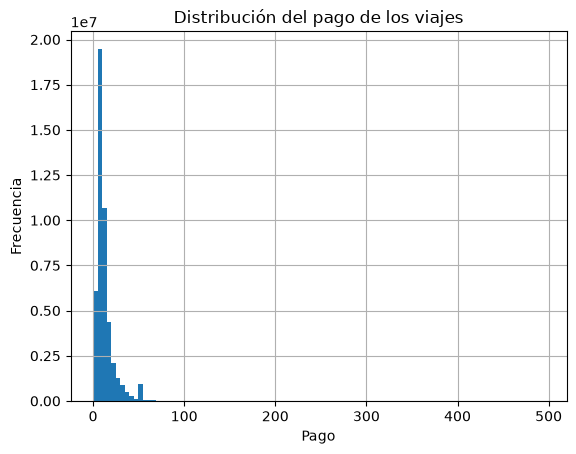

In [9]:
#Análisis de la distancia de los viajes. Vamos a ver cómo se distribuyen las distancias de los viajes en el dataset.
data['trip_distance'].hist(bins=100)
plt.title('Distribución de la distancia de los viajes')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')
#Análisis del pago de los viajes. Vamos a ver cómo se distribuyen los pagos de los viajes en el dataset.
plt.figure()
data['fare_amount'].hist(bins=100)
plt.xlabel('Pago')
plt.ylabel('Frecuencia')
plt.title('Distribución del pago de los viajes')

In [10]:
#Miremos qué relaciones pueden aparecer entre los pagos y las distancias
import plotly.express as px
px.scatter(x='trip_distance', y='fare_amount', data_frame=data.sample(100000), color='month', size='total_amount', hover_data=['passenger_count', 'payment_type'], title='Relación entre distancia y duración del viaje')

passenger_count
1    7.094137e-01
2    1.424150e-01
3    4.056227e-02
4    1.931954e-02
5    5.415242e-02
6    3.413498e-02
7    7.038946e-07
8    6.825644e-07
9    7.038946e-07
Name: count, dtype: float64


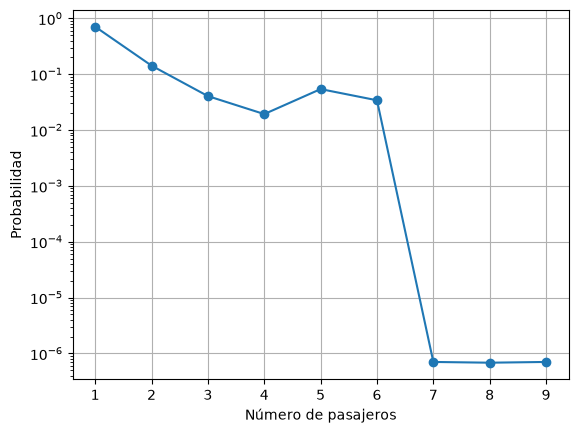

In [11]:
#Hagamos el análisis de probabilidad del número de pasajeros. Vamos a ver cómo se distribuye el número de pasajeros en los viajes del dataset.
cnt=data['passenger_count'].value_counts().sort_index()
pr=cnt/cnt.sum()
plt.semilogy(pr.index, pr.values, marker='o')
plt.ylabel('Probabilidad')
plt.xlabel('Número de pasajeros')
plt.grid()
print(pr)

Probabilidad de no pagar paeajes: 0.9521605084422556
Probabilidad de pagar $0.01 en peajes: 0.0017
Probabilidad de pagar $2.51 en peajes: 0.0032
Probabilidad de pagar $5.01 en peajes: 0.3743
Probabilidad de pagar $7.51 en peajes: 0.0018
Probabilidad de pagar $10.01 en peajes: 0.0111
Probabilidad de pagar $12.51 en peajes: 0.0015
Probabilidad de pagar $15.01 en peajes: 0.0038
Probabilidad de pagar $17.51 en peajes: 0.0016
Probabilidad de pagar $20.01 en peajes: 0.0005
Probabilidad de pagar $22.51 en peajes: 0.0003
Probabilidad de pagar $25.01 en peajes: 0.0001
Probabilidad de pagar $27.51 en peajes: 0.0001
Probabilidad de pagar $30.01 en peajes: 0.0000


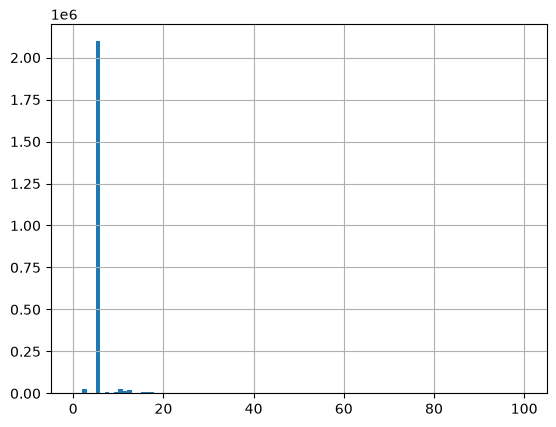

In [12]:
#Hagamos el análisis de probabilidad del valor pagado en peajes en la ruta
print('Probabilidad de no pagar paeajes:', len((data[data['tolls_amount']==0])) / len(data))
cnt=data[data['tolls_amount']>0]['tolls_amount'].hist(bins=100)
pr, bins=np.histogram(data[data['tolls_amount']>0]['tolls_amount'], bins=40, density=True)
for pi, bi in zip(pr, bins):
    if(bi<=32):
        print(f'Probabilidad de pagar ${bi:.2f} en peajes: {pi:.4f}')

In [13]:
#Observe que los datos del dataframe tienen mucha información. 
#La función de la estadística descriptiva nos da una idea de la distribución de los datos
# a nive univariable y de la relación entre las variables a nivel multivariable
data.info()

<class 'pandas.DataFrame'>
Index: 46882020 entries, 0 to 47248844
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        int64         
 3   trip_distance          float64       
 4   pickup_longitude       float64       
 5   pickup_latitude        float64       
 6   RateCodeID             float64       
 7   dropoff_longitude      float64       
 8   dropoff_latitude       float64       
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  day_of_week            int32         
 18  hour_of_day            int32        

In [14]:
#Por favor piense en otras relaciones, hipótesis que quiera validar dentro de los datos
#y realice los análisis correspondientes. Por ejemplo, puede analizar la relación entre el día de la semana y la hora del día con el número de pasajeros, 
# la distancia del viaje y el pago total. También puede explorar cómo varían los pagos de peajes según la distancia del viaje o el número de pasajeros.
